In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# CSV oku
df = pd.read_csv("/content/IMDB Dataset.csv", engine='python')
print("Dataset boyutu:", df.shape)
print(df['sentiment'].value_counts())
df.head()

Dataset boyutu: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [13]:
# Label encode
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

# Split
X_train, X_test, y_train, y_test = train_test_split(df['review'], df['sentiment'], test_size=0.2, random_state=42)

print("Train boyutu:", len(X_train))
print("Test boyutu:", len(X_test))

Train boyutu: 40000
Test boyutu: 10000


In [14]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF matrisi shape:", X_train_tfidf.shape)

TF-IDF matrisi shape: (40000, 10000)


In [15]:
model = LogisticRegression(solver='liblinear')
model.fit(X_train_tfidf, y_train)

LogisticRegression(solver='liblinear')

Accuracy: 0.9038
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4961
           1       0.90      0.92      0.91      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



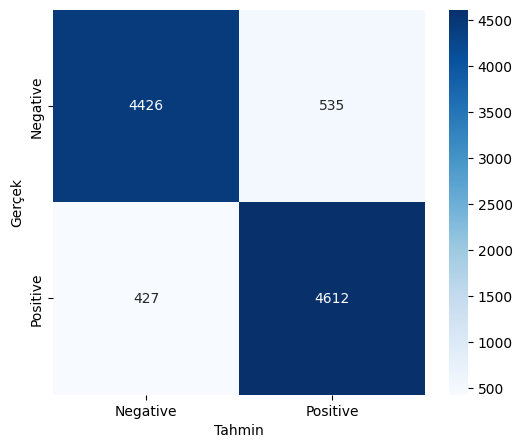

In [16]:
y_pred = model.predict(X_test_tfidf)

# Accuracy ve rapor
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix görselleştirme
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.show()

In [17]:
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # HTML tag temizle
    text = re.sub(r'<.*?>', ' ', text)
    # Küçük harfe çevir
    text = text.lower()
    # Noktalama ve özel karakterleri çıkar
    text = re.sub(r'[^a-z\s]', '', text)
    # Stopwords çıkar
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['review_clean'] = df['review'].apply(clean_text)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,sentiment,review_clean
0,One of the other reviewers has mentioned that ...,1,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love time money visually stunni...


In [18]:
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['review_clean'])
y = df['sentiment'].map({'positive':1, 'negative':0})

# Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# TF-IDF (temiz veri + ngram)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1,2))

X = vectorizer.fit_transform(df['review_clean'])
y = df['sentiment']  # ❗ map YOK

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X shape:", X.shape)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

X shape: (50000, 15000)
Train: (40000, 15000)
Test: (10000, 15000)


Accuracy: 0.8998
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



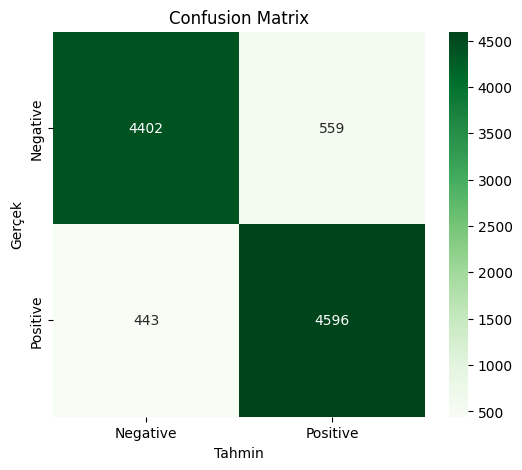

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Model
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)

# Tahmin
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detaylı rapor
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()